In [2]:
import pandas as pd
import numpy as np

df = pd.read_parquet("../../cleaned_data.parquet")

In [3]:
# Only keep top n complaints. Dont really want noises and rare complaints 
TOP_N = 50
top_complaints = df['Complaint Type'].value_counts().nlargest(TOP_N).index
# top_complaints

# Keep only the rows whose complaints are in the top n categories
df_filtered = df[df['Complaint Type'].isin(top_complaints)]
df_filtered.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,City,Status,Community Board,Borough,X Coordinate (State Plane),Y Coordinate (State Plane),Open Data Channel Type,Park Borough,Latitude,Longitude
51,66344971,2025-10-03 01:19:28,2025-10-03 01:29:18,NYPD,NEW YORK CITY POLICE DEPARTMENT,NOISE - COMMERCIAL,LOUD MUSIC/PARTY,CLUB/BAR/RESTAURANT,10014,51 8 AVENUE,...,NEW YORK,CLOSED,02 MANHATTAN,MANHATTAN,983178,208405,PHONE,MANHATTAN,40.7387,-74.003868
54,66347424,2025-10-03 01:18:35,2025-10-03 01:31:44,NYPD,NEW YORK CITY POLICE DEPARTMENT,BLOCKED DRIVEWAY,PARTIAL ACCESS,STREET/SIDEWALK,11693,204 BEACH 79 STREET,...,FAR ROCKAWAY,CLOSED,14 QUEENS,QUEENS,1038366,153702,ONLINE,QUEENS,40.588387,-73.805159
56,66350619,2025-10-03 01:16:18,2025-10-03 01:32:52,NYPD,NEW YORK CITY POLICE DEPARTMENT,ENCAMPMENT,UNKNOWN,RESIDENTIAL BUILDING/HOUSE,10456,1398 GRAND CONCOURSE,...,BRONX,CLOSED,04 BRONX,BRONX,1008079,244798,ONLINE,BRONX,40.838557,-73.913883
57,66348800,2025-10-03 01:15:29,2025-10-03 01:21:49,NYPD,NEW YORK CITY POLICE DEPARTMENT,NOISE - RESIDENTIAL,LOUD MUSIC/PARTY,RESIDENTIAL BUILDING/HOUSE,11233,310 PATCHEN AVENUE,...,BROOKLYN,CLOSED,03 BROOKLYN,BROOKLYN,1004921,187036,ONLINE,BROOKLYN,40.680023,-73.925473
61,66345021,2025-10-03 01:13:43,2025-10-03 01:19:37,NYPD,NEW YORK CITY POLICE DEPARTMENT,NOISE - RESIDENTIAL,BANGING/POUNDING,RESIDENTIAL BUILDING/HOUSE,11104,43-09 40 STREET,...,SUNNYSIDE,CLOSED,02 QUEENS,QUEENS,1005317,210789,MOBILE,QUEENS,40.745219,-73.923971


In [4]:
zip_issues_matrix = pd.crosstab(df_filtered['Incident Zip'], df_filtered['Complaint Type'])

zip_issues_pct = zip_issues_matrix.div(zip_issues_matrix.sum(axis=1), axis=0)
zip_issues_pct = zip_issues_pct.fillna(0)

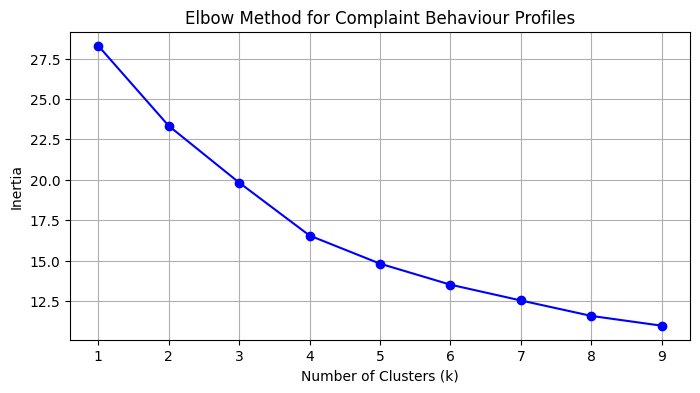

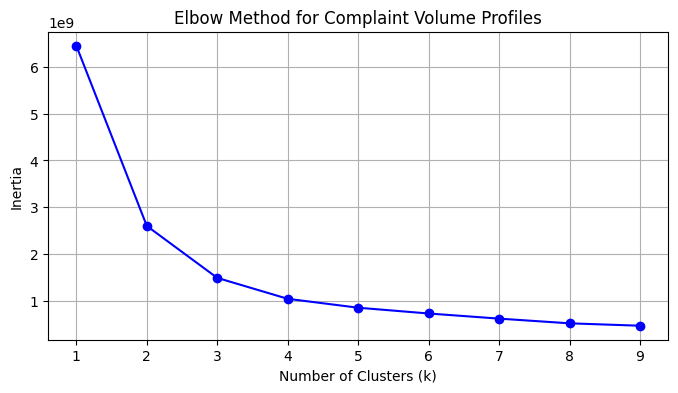

In [5]:
# K means algorithm
from utils import plot_elbow

# Determine the optimal n for k-means using elbow graph
plot_elbow(zip_issues_pct, "Elbow Method for Complaint Behaviour Profiles")
plot_elbow(zip_issues_matrix, "Elbow Method for Complaint Volume Profiles")


In [18]:
from sklearn.cluster import KMeans

# Optimal k looks like 3 4 or 5
OPTIMAL_K = 5

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
clusters = kmeans.fit_predict(zip_issues_pct)

# Add labels back to the dataframe for analysis
zip_issues_pct['Cluster'] = clusters

# Calculating the mean percentage of each complaint type for each cluster.
cluster_profiles = zip_issues_pct.groupby('Cluster').mean()

print("\n--- Cluster Interpretations ---")
for i in range(OPTIMAL_K):
    print(f"\nCluster {i} ({len(zip_issues_pct[zip_issues_pct['Cluster']==i])} Zips):")
    # Get top 3 dominant issues for this cluster
    top_issues = cluster_profiles.loc[i].sort_values(ascending=False).head(3)
    for issue, pct in top_issues.items():
        print(f"  - {issue}: {pct:.1%}")

# 5. Save Results
# We merge the cluster labels back to a simple CSV for mapping/reporting
results = zip_issues_pct[['Cluster']].reset_index()
# results.to_csv("../../results/clustering/zip_code_issue_behaviour_clusters.csv", index=False)
zip_issues_pct['Cluster'].value_counts()


--- Cluster Interpretations ---

Cluster 0 (24 Zips):
  - ILLEGAL PARKING: 54.4%
  - BLOCKED DRIVEWAY: 4.5%
  - NOISE - RESIDENTIAL: 3.4%

Cluster 1 (95 Zips):
  - ILLEGAL PARKING: 24.3%
  - NOISE - RESIDENTIAL: 6.6%
  - HOMELESS PERSON ASSISTANCE: 6.6%

Cluster 2 (102 Zips):
  - NOISE - RESIDENTIAL: 12.5%
  - ILLEGAL PARKING: 11.0%
  - HEAT/HOT WATER: 8.2%

Cluster 3 (18 Zips):
  - VENDOR ENFORCEMENT: 46.9%
  - TRAFFIC SIGNAL CONDITION: 5.6%
  - ILLEGAL PARKING: 5.3%

Cluster 4 (5 Zips):
  - CONSUMER COMPLAINT: 73.3%
  - DEAD ANIMAL: 20.0%
  - ILLEGAL PARKING: 6.7%


Cluster
2    102
1     95
0     24
3     18
4      5
Name: count, dtype: int64

--- Starting Map Generation ---
Calculating zip code centroids...
Loading map from ../../geo_data.geojson...
Performing spatial join...


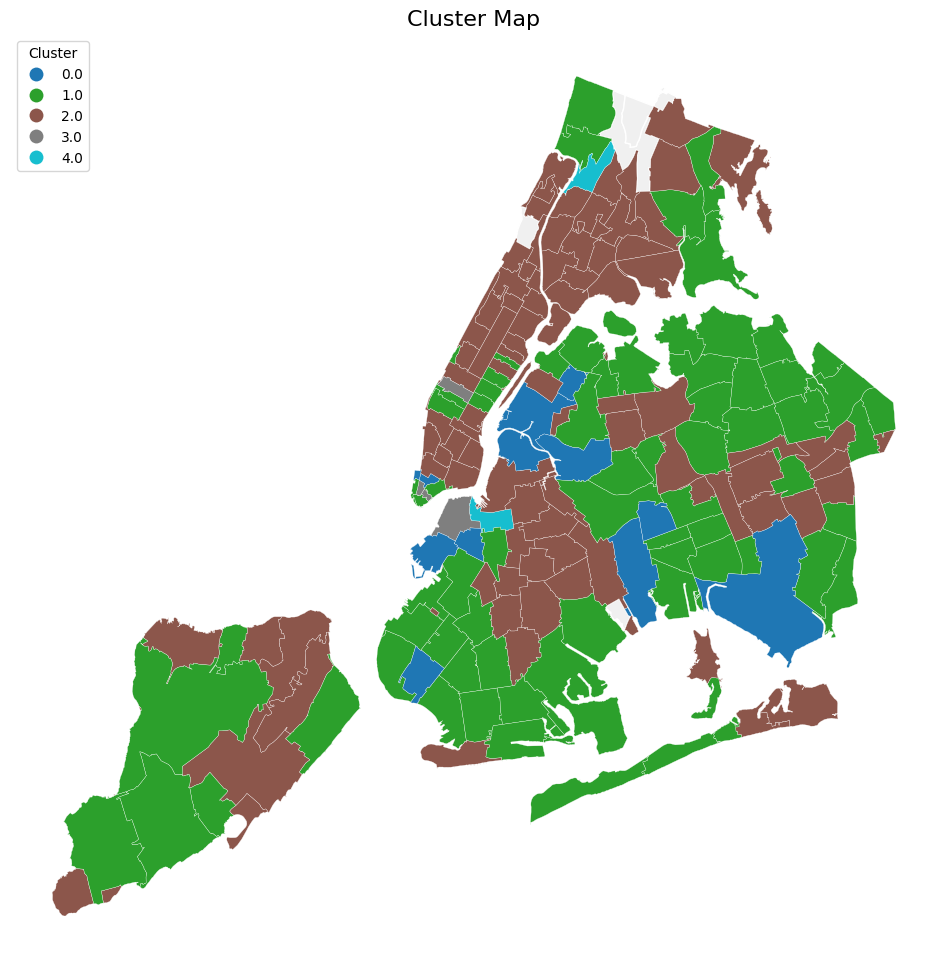

--- Map Generation Complete ---


In [19]:
from utils import plot_cluster_map


# clusters_df = pd.read_csv("../../results/clustering/zip_code_issue_behaviour_clusters.csv")
# clusters_df['Incident Zip'] = clusters_df['Incident Zip'].astype(str).str.strip()
plot_cluster_map(results)